In [20]:
import nibabel as nib
import numpy as np
from pathlib import Path
from skimage.transform import rotate
from skimage.util import montage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from helper import get_filepath, format_index
import re 
from collections import Counter
from pathlib import Path
from dotenv import dotenv_values, find_dotenv
import os

config = {
    **dotenv_values(find_dotenv(usecwd=True)),
    **os.environ
}

UNPROCESSED_DATASET_PATH = Path(config["UNPROCESSED_DATASET_PATH"])

# Data inspection

# 1. No. files and indexing

In [21]:
pattern = re.compile(r"BraTS20_Training_(\d+)")
pattern_val = re.compile(r"BraTS20_Validation_(\d+)")

scan_dirs = []
indices = []
scan_dirs_val = []
indices_val = []

for item in UNPROCESSED_DATASET_PATH.iterdir():
    if item.is_dir():
        match = pattern.match(item.name)
        if match:
            scan_dirs.append(item)
            indices.append(int(match.group(1)))

print(f"Number of scans - Training: {len(scan_dirs)}")
if indices:
    print(f"Minimum index: {min(indices)}")
    print(f"Maximum index: {max(indices)}")

Number of scans - Training: 369
Minimum index: 1
Maximum index: 369



## 1. Data format and basic information

### 1.1 What is NIfTI?
The dataset used in this project is stored in the **NIfTI** format (`.nii`), which is one of the standard file formats for medical imaging and neuroimaging tasks. 

NIfTI stands for Neuroimaging Informatics Technology Initiative and was designed specifically for storing volumetric medical scan data such as MRI and CT images.

### 1.2 What does NIfTI contain?

A NIfTI file contains two main components: the image data itself and a header containing metadata.

#### 1.2.1 Image data

A `.nii` file stores 3D or 4D data rather than a single 2D image. In brain tumor segmentation tasks, each scan is typically represented as a three-dimensional volume made up of multiple 2D image slices stacked together. Each voxel (the 3D equivalent of a pixel) contains an intensity value representing tissue properties captured during the scan.

#### 1.2.2 Metadata

The header stores information such as image dimensions, voxel spacing, orientation, datatype, and coordinate system. This metadata is especially important in medical imaging because it preserves the spatial structure of the scan, allowing models and visualization tools to correctly interpret anatomical locations.

### 1.3 Loading data

We will use the NiBabel library which lets us load the .nii files to a NumPy array.

#### 1.3.1 Basic info and dimensions

In [22]:
path = get_filepath(1)
img = nib.load(path)


print("\n--- Basic NIfTI Information ---")

print(f"File path: {path}")
print(f"Shape: {img.shape}")
print(f"Data type: {img.get_data_dtype()}")
print(f"Voxel size: {img.header.get_zooms()}")


--- Basic NIfTI Information ---
File path: /media/stabur/Windows-SSD/Users/Mathman/Desktop/brain-seg/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii
Shape: (240, 240, 155)
Data type: int16
Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


These 3 dimensions (240,240,155) correspond to the three spatial dimensions of the image: width, height, and depth. In medical imaging, these dimensions are referred to as the axial (transverse), coronal, and sagittal planes, corresponding to the three main orientations of the human body and, therefore, the human brain.

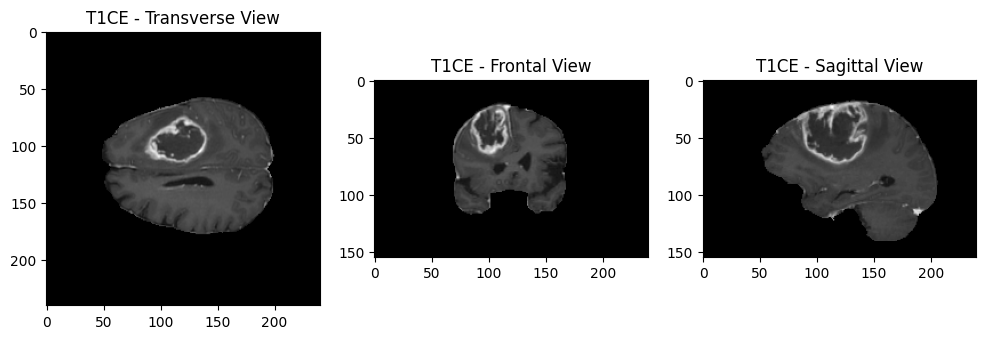

In [23]:
slice = 95

path = get_filepath(355,"t1ce")
img = nib.load(path)
data = img.get_fdata()

plt.figure(figsize=(12, 8))

# Topdown 
plt.subplot(1, 3, 1)
plt.imshow(data[:,:,slice], cmap='gray')
plt.title('T1CE - Transverse View')

# Frontal
plt.subplot(1, 3, 2)
plt.imshow(rotate(data[:,slice,:], 90, resize=True), cmap='gray')
plt.title('T1CE - Frontal View')

# Side
plt.subplot(1, 3, 3)
plt.imshow(rotate(data[slice,:,:], 90, resize=True), cmap='gray')
plt.title('T1CE - Sagittal View')
plt.show()

#### 1.3.2 Missing slices?

In [24]:
missing = {}
for folder in range(min(indices), max(indices) + 1):

    path = get_filepath(folder)
    img = nib.load(path)

    if img.shape[2] != 155:
        missing[folder] = 155 - img.shape[2]
    
if missing:
    print(missing)
else: 
    print("No missing slices.")

No missing slices.


### 1.4 Labels

All the imaging datasets have been segmented manually, by one to four raters, following the same annotation protocol, and their annotations were approved by experienced neuro-radiologists. Annotations comprise the **GD-enhancing tumor (ET — label 4)**, the **peritumoral edema (ED — label 2)**, and the **necrotic and non-enhancing tumor core (NCR/NET — label 1)**, as described both in the BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper. 

Additionaly we have **label 0** representing the background and **label 3** for missing voxels.

In [25]:
label_counts = Counter()

for folder in range(min(indices), max(indices)):

    seg_path = get_filepath(folder, "seg")
    seg_img = nib.load(seg_path)

    seg_data = np.asarray(seg_img.dataobj)

    unique, counts = np.unique(seg_data, return_counts=True)

    for label, count in zip(unique, counts):
        label_counts[int(label)] += int(count)


print("\nVoxel label counts:\n")

for label in sorted(label_counts.keys()):
    print(f"Label {label}: {label_counts[label]:,}")

print("\nLabels present:")
print(sorted(label_counts.keys()))


Voxel label counts:

Label 0: 3,248,996,108
Label 1: 8,141,407
Label 2: 21,140,796
Label 4: 7,225,689

Labels present:
[0, 1, 2, 4]


As there are no missing voxel (labels 3), we will be relabeling the GD-enhancing tumor as label 3 instead of 4.

3,2 B background pixels is a lot, we will take a look at this later.


### 1.5 Modalities
The dataset contains four MRI modalities, each providing different information about brain tissue and tumor structure.

**T1-weighted (T1)**
- Provides good anatomical detail of the brain structure. Healthy tissues such as white matter and gray matter are clearly distinguishable, making this modality useful for observing the general anatomy.

**T1-weighted with contrast enhancement (T1ce)**
- A contrast agent is administered before scanning, causing active tumor regions to appear brighter. This modality is particularly useful for identifying enhancing tumor tissue and tumor boundaries.

**T2-weighted (T2)**
- Highlights fluid-containing regions, making edema and abnormal tissue appear bright. It is useful for detecting swelling around the tumor.

**FLAIR (Fluid Attenuated Inversion Recovery)**
- Similar to T2, but suppresses signals from cerebrospinal fluid (CSF). This makes lesions and edema easier to observe without interference from bright fluid regions.

In [26]:
modalities = ["t1", "t1ce", "t2", "flair", "seg"]
cmap = ListedColormap([
    "black",  # background
    "red",    # necrotic
    "green",  # edema
    "yellow"  # enhancing tumor
])

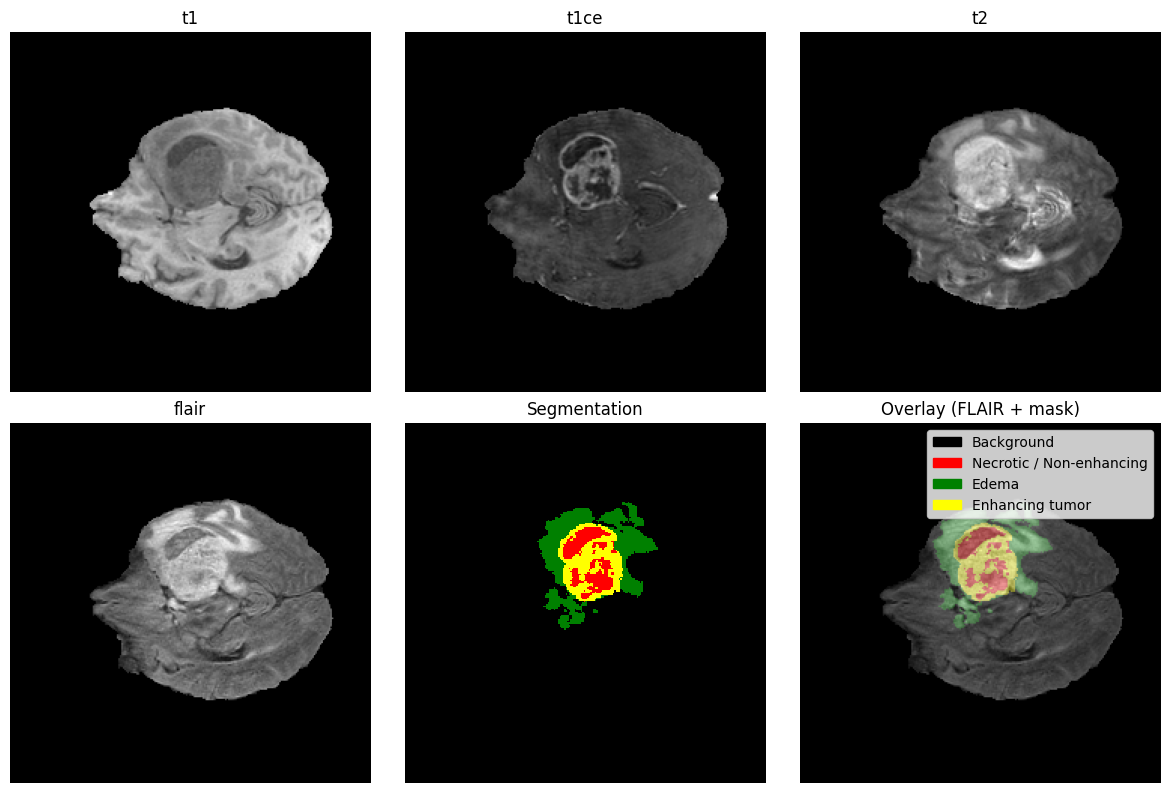

In [27]:
def visualize_brain(brain_index, slice_index):

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    images = {}
    
    for mod in modalities:
        path = get_filepath(brain_index, mod)
        img = nib.load(path)
        data = img.get_fdata()
        images[mod] = data[:, :, slice_index]


    # Plot modalities
    for i, mod in enumerate(["t1", "t1ce", "t2", "flair"]):
        axes[i].imshow(images[mod], cmap="gray")
        axes[i].set_title(mod)
        axes[i].axis("off")


    # Segmentation mask
    seg = images["seg"].copy()

    seg[seg == 4] = 3

    axes[4].imshow(seg, cmap=cmap, interpolation="nearest")
    axes[4].set_title("Segmentation")
    axes[4].axis("off")


    # Overlay (FLAIR + mask)
    flair = images["flair"]

    axes[5].imshow(flair, cmap="gray")
    axes[5].imshow(seg, cmap=cmap, alpha=0.35)
    axes[5].set_title("Overlay (FLAIR + mask)")
    axes[5].axis("off")

    patches = [
        mpatches.Patch(color="black", label="Background"),
        mpatches.Patch(color="red", label="Necrotic / Non-enhancing"),
        mpatches.Patch(color="green", label="Edema"),
        mpatches.Patch(color="yellow", label="Enhancing tumor"),
    ]

    axes[5].legend(handles=patches, loc="upper right")

    plt.tight_layout()
    plt.show()

visualize_brain(1,59)

## 2. Empty Masks

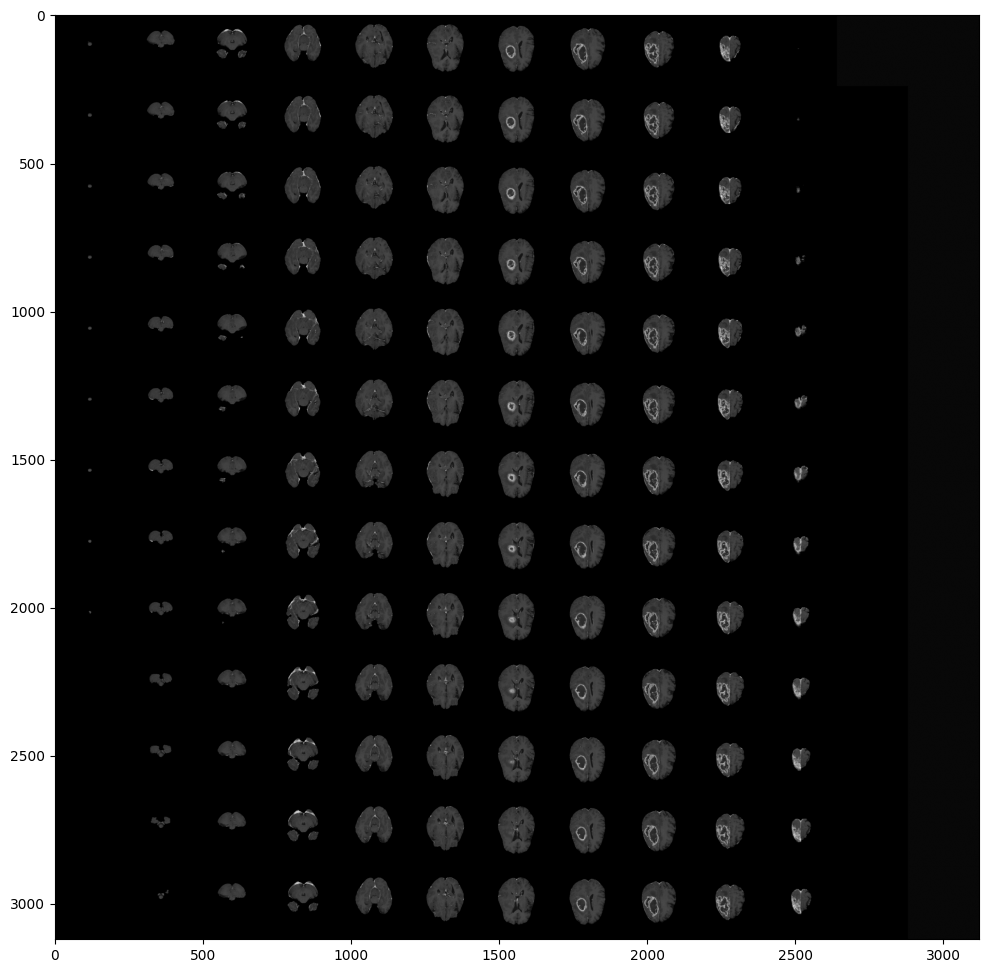

In [28]:
plt.figure(figsize=(17, 12))

path = get_filepath(355,"t1ce")
img = nib.load(path)
data = img.get_fdata()

plt.imshow(rotate(montage(data[:,:,:].transpose(2, 0, 1)), 90, resize=True), cmap ='gray');

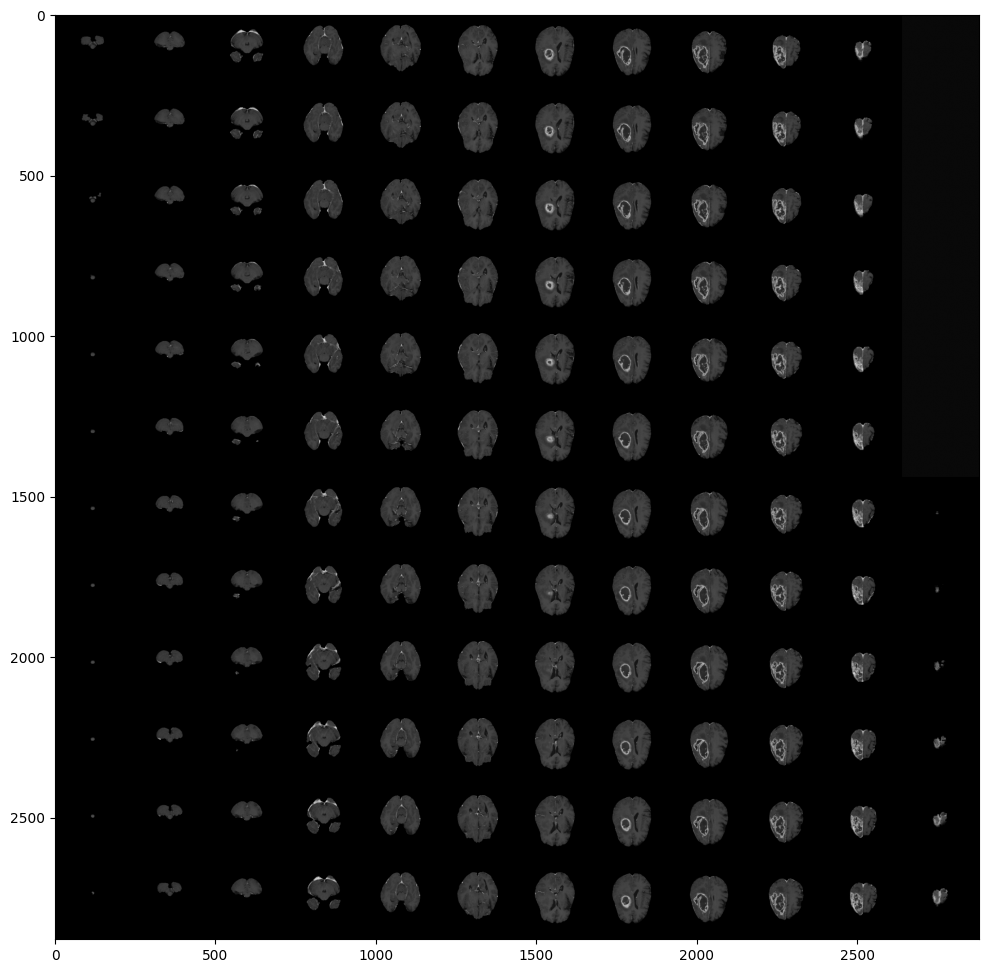

In [29]:
plt.figure(figsize = (15,12))
plt.imshow(rotate(montage(data[:,:,4:-13].transpose(2,0,1)), 90, resize=True), cmap ='gray');

This shows that a moderate part of every scan consists of empty masks, as slices from the start and end of a scan capture areas outside the brain which give us no information. Which might let us save a bit of time during training.